In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/Patient_Data (1).csv')
df

,PatientID,Name,Department,Doctor,BillAmount,ReceptionistID,CheckInTime
0,101,Alice,Cardiology,Dr. Smith,5000.0,1,2023-01-10 09:00
1,102,Bob,Neurology,Dr. John,NaN,2,2023-01-11 10:30
2,103,Charlie,Orthopedics,Dr. Lee,7500.0,1,2023-01-12 11:00
3,104,David,Cardiology,Dr. Smith,6200.0,3,2023-01-13 12:00
4,105,Eva,Dermatology,Dr. Rose,NaN,2,2023-01-14 08:45
5,101,Alice,Cardiology,Dr. Smith,5000.0,1,2023-01-10 09:00


In [4]:
df.head()

,PatientID,Name,Department,Doctor,BillAmount,ReceptionistID,CheckInTime
0,101,Alice,Cardiology,Dr. Smith,5000.0,1,2023-01-10 09:00
1,102,Bob,Neurology,Dr. John,NaN,2,2023-01-11 10:30
2,103,Charlie,Orthopedics,Dr. Lee,7500.0,1,2023-01-12 11:00
3,104,David,Cardiology,Dr. Smith,6200.0,3,2023-01-13 12:00
4,105,Eva,Dermatology,Dr. Rose,NaN,2,2023-01-14 08:45


In [5]:
df.info

<bound method DataFrame.info of    PatientID     Name   Department     Doctor  BillAmount  ReceptionistID  \
0        101    Alice   Cardiology  Dr. Smith      5000.0               1   
1        102      Bob    Neurology   Dr. John         NaN               2   
2        103  Charlie  Orthopedics    Dr. Lee      7500.0               1   
3        104    David   Cardiology  Dr. Smith      6200.0               3   
4        105      Eva  Dermatology   Dr. Rose         NaN               2   
5        101    Alice   Cardiology  Dr. Smith      5000.0               1   

        CheckInTime  
0  2023-01-10 09:00  
1  2023-01-11 10:30  
2  2023-01-12 11:00  
3  2023-01-13 12:00  
4  2023-01-14 08:45  
5  2023-01-10 09:00  >

In [6]:
df.shape

(6, 7)

In [8]:
df.isnull().sum()

,0
PatientID,0
Name,0
Department,0
Doctor,0
BillAmount,2
ReceptionistID,0
CheckInTime,0


In [9]:
df.duplicated().sum()

np.int64(1)

<Axes: >

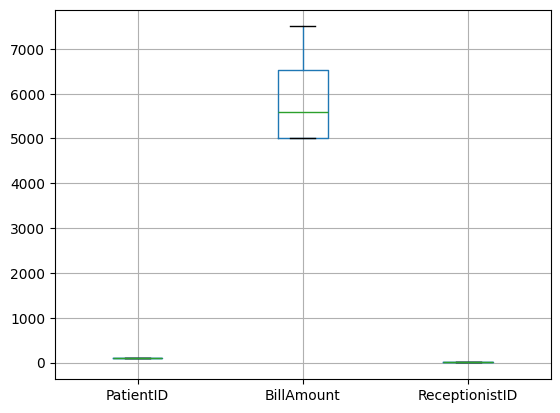

In [10]:
df.boxplot()

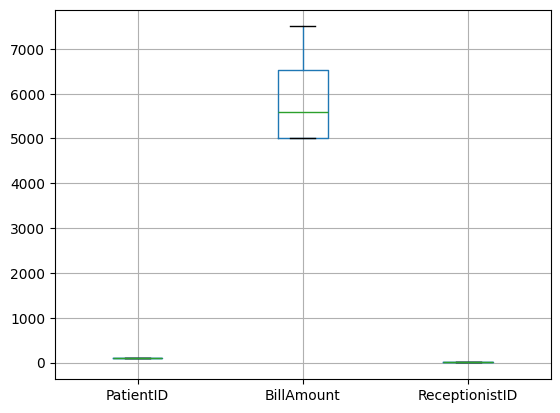

In [11]:
#Checking outliers
df.boxplot()
plt.show()

In [12]:
# 2. Select billing-related columns
billing_df = df[['PatientID', 'Department', 'Doctor', 'BillAmount']]
print('\n--- Billing Columns ---')
print(billing_df)

# 3. Drop administrative columns
df_clean = df.drop(['ReceptionistID', 'CheckInTime'], axis=1)
print('\n--- After Dropping Admin Columns ---')
print(df_clean)

# 4. Total bill amount per department
dept_bill = df.groupby('Department')['BillAmount'].sum()
print('\n--- Total Bill Amount by Department ---')
print(dept_bill)

# 5. Remove duplicate patient records
df_nodup = df_clean.drop_duplicates(subset='PatientID')
print('\n--- After Removing Duplicates ---')
print(df_nodup)



--- Billing Columns ---
   PatientID   Department     Doctor  BillAmount
0        101   Cardiology  Dr. Smith      5000.0
1        102    Neurology   Dr. John         NaN
2        103  Orthopedics    Dr. Lee      7500.0
3        104   Cardiology  Dr. Smith      6200.0
4        105  Dermatology   Dr. Rose         NaN
5        101   Cardiology  Dr. Smith      5000.0

--- After Dropping Admin Columns ---
   PatientID     Name   Department     Doctor  BillAmount
0        101    Alice   Cardiology  Dr. Smith      5000.0
1        102      Bob    Neurology   Dr. John         NaN
2        103  Charlie  Orthopedics    Dr. Lee      7500.0
3        104    David   Cardiology  Dr. Smith      6200.0
4        105      Eva  Dermatology   Dr. Rose         NaN
5        101    Alice   Cardiology  Dr. Smith      5000.0

--- Total Bill Amount by Department ---
Department
Cardiology     16200.0
Dermatology        0.0
Neurology          0.0
Orthopedics     7500.0
Name: BillAmount, dtype: float64

--- After 

In [13]:
# 6. Fill missing BillAmount values with mean
mean_bill = df_nodup['BillAmount'].mean()
df_nodup['BillAmount'] = df_nodup['BillAmount'].fillna(mean_bill)

print('\nMean Bill Amount:', mean_bill)
print('\n--- After Filling Missing BillAmount ---')
print(df_nodup)




Mean Bill Amount: 6233.333333333333

--- After Filling Missing BillAmount ---
   PatientID     Name   Department     Doctor   BillAmount
0        101    Alice   Cardiology  Dr. Smith  5000.000000
1        102      Bob    Neurology   Dr. John  6233.333333
2        103  Charlie  Orthopedics    Dr. Lee  7500.000000
3        104    David   Cardiology  Dr. Smith  6200.000000
4        105      Eva  Dermatology   Dr. Rose  6233.333333


/tmp/ipykernel_9377/3420491382.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nodup['BillAmount'] = df_nodup['BillAmount'].fillna(mean_bill)


In [15]:
# 7. Create a sample billing dataset and merge
billing = pd.DataFrame({
    'PatientID': [101, 102, 103, 104, 105, 106],
    'PaymentMode': ['Cash', 'Card', 'Insurance', 'Cash', 'Card', 'Cash'],
    'PaidAmount': [5000, 5500, 7000, 6500, 4000, 8000]
})

merged_df = pd.merge(df_nodup, billing, on='PatientID', how='left')

print('\n--- Merged Dataset ---')
print(merged_df)

# 8. Add new patients (row-wise)
new_patients = pd.DataFrame({
    'PatientID': [107, 108],
    'Name': ['Pooja', 'Mohan'],
    'Department': ['ENT', 'Cardiology'],
    'Doctor': ['Dr. D', 'Dr. A'],
    'BillAmount': [4500, 7200],
    'PaymentMode': ['Cash', 'Insurance'],
    'PaidAmount': [4500, 7000]
})



--- Merged Dataset ---
   PatientID     Name   Department     Doctor   BillAmount PaymentMode  \
0        101    Alice   Cardiology  Dr. Smith  5000.000000        Cash   
1        102      Bob    Neurology   Dr. John  6233.333333        Card   
2        103  Charlie  Orthopedics    Dr. Lee  7500.000000   Insurance   
3        104    David   Cardiology  Dr. Smith  6200.000000        Cash   
4        105      Eva  Dermatology   Dr. Rose  6233.333333        Card   

   PaidAmount  
0        5000  
1        5500  
2        7000  
3        6500  
4        4000  


In [16]:
final_df = pd.concat([merged_df, new_patients], ignore_index=True)

# 9. Add new billing category columns (column-wise)
new_cols = pd.DataFrame({
    'InsuranceCovered': [0, 1, 1, 0, 0, 0, 1, 1],
    'FinalAmount': [5000, 5000, 6500, 6500, 4000, 8000, 4500, 7000]
})

final_df = pd.concat([final_df, new_cols], axis=1)

print('\n--- Final Cleaned Dataset ---')
print(final_df)


--- Final Cleaned Dataset ---
   PatientID     Name   Department     Doctor   BillAmount PaymentMode  \
0      101.0    Alice   Cardiology  Dr. Smith  5000.000000        Cash   
1      102.0      Bob    Neurology   Dr. John  6233.333333        Card   
2      103.0  Charlie  Orthopedics    Dr. Lee  7500.000000   Insurance   
3      104.0    David   Cardiology  Dr. Smith  6200.000000        Cash   
4      105.0      Eva  Dermatology   Dr. Rose  6233.333333        Card   
5      107.0    Pooja          ENT      Dr. D  4500.000000        Cash   
6      108.0    Mohan   Cardiology      Dr. A  7200.000000   Insurance   
7        NaN      NaN          NaN        NaN          NaN         NaN   

   PaidAmount  InsuranceCovered  FinalAmount  
0      5000.0                 0         5000  
1      5500.0                 1         5000  
2      7000.0                 1         6500  
3      6500.0                 0         6500  
4      4000.0                 0         4000  
5      4500.0       